# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [2]:
%pip install tslearn -q
%pip install scipy scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.random.seed(0)

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import os
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

In [4]:
from aeon.datasets import load_from_ts_file
from scipy.signal import resample

DATA_PATH = "./CatsDogs"

X_train_aeon, y_train = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TRAIN.ts"))
X_test_aeon,  y_test  = load_from_ts_file(os.path.join(DATA_PATH, "CatsDogs_TEST.ts"))

print(f"Форма aeon (обучение): {X_train_aeon.shape}")
print(f"Классы: {np.unique(y_train)}")

DOWNSAMPLE_LEN = 300

def downsample_collection(X, target_len):
    n_cases, n_channels, _ = X.shape
    X_out = np.zeros((n_cases, n_channels, target_len))
    for i in range(n_cases):
        for c in range(n_channels):
            X_out[i, c, :] = resample(X[i, c, :], target_len)
    return X_out

X_train_ds = downsample_collection(X_train_aeon, DOWNSAMPLE_LEN)
X_test_ds  = downsample_collection(X_test_aeon,  DOWNSAMPLE_LEN)


X_train_ts = X_train_ds.transpose(0, 2, 1)  # (164, 300, 1)
X_test_ts  = X_test_ds.transpose(0, 2, 1)   # (164, 300, 1)

print(f"Форма tslearn (обучение): {X_train_ts.shape}")
print(f"Форма tslearn (тест):     {X_test_ts.shape}")
print(f"Распределение классов: { {c: int((y_train==c).sum()) for c in np.unique(y_train)} }")

Форма aeon (обучение): (164, 1, 14773)
Классы: ['0' '1']
Форма tslearn (обучение): (164, 300, 1)
Форма tslearn (тест):     (164, 300, 1)
Распределение классов: {np.str_('0'): 82, np.str_('1'): 82}


#### EDA

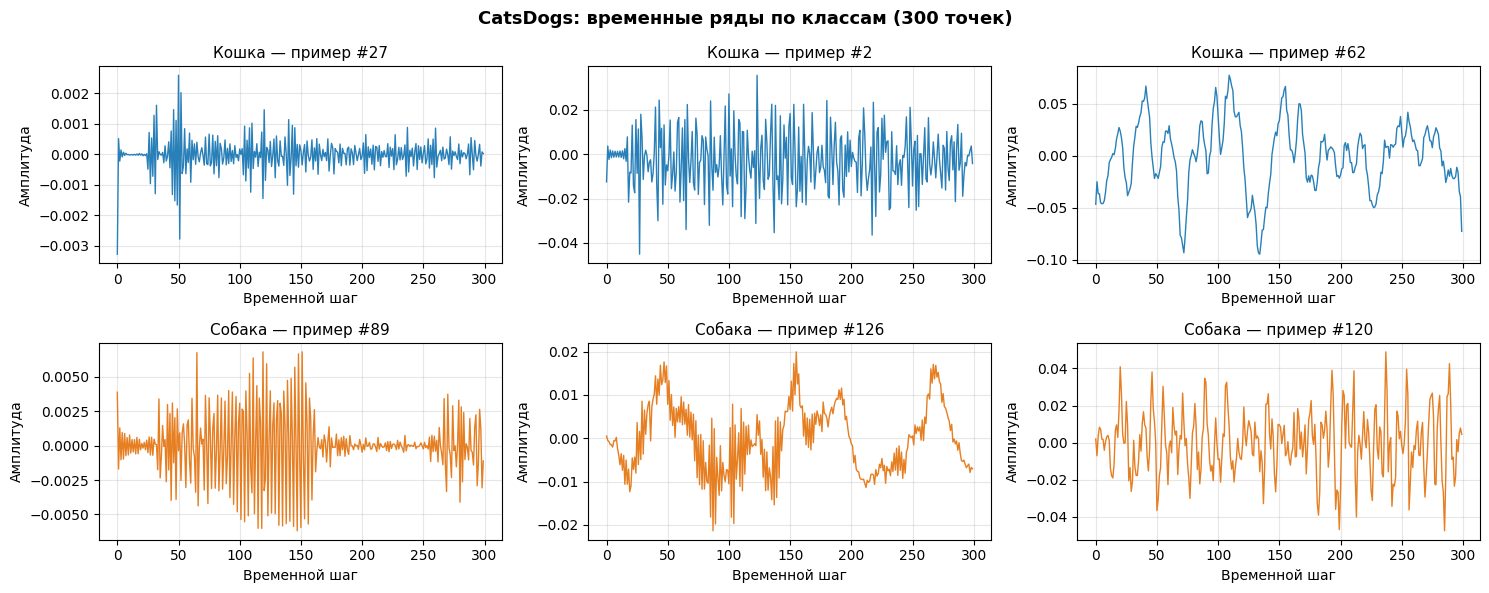

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
class_names = {"0": "Кошка", "1": "Собака"}
colors = {"0": "#2980b9", "1": "#e67e22"}

for row, cls in enumerate(np.unique(y_train)):
    idx = np.where(y_train == cls)[0]
    label = class_names.get(cls, f"Класс {cls}")
    color = colors.get(cls, "green")
    sample_ids = np.random.choice(idx, size=3, replace=False)
    for col, sid in enumerate(sample_ids):
        # X_train_ts: (n_cases, n_timepoints, n_channels)
        axes[row, col].plot(X_train_ts[sid, :, 0], color=color, linewidth=1.0)
        axes[row, col].set_title(f"{label} — пример #{sid}", fontsize=11)
        axes[row, col].set_xlabel("Временной шаг")
        axes[row, col].set_ylabel("Амплитуда")
        axes[row, col].grid(True, alpha=0.3)

plt.suptitle("CatsDogs: временные ряды по классам (300 точек)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### KNN с метрикой DTW

In [6]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

knn_dtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=1,
    metric="dtw",
    metric_params={"sakoe_chiba_radius": 30},
    n_jobs=-1
)
knn_dtw.fit(X_train_ts, y_train)
preds_knn_dtw = knn_dtw.predict(X_test_ts)
acc_knn_dtw = accuracy_score(y_test, preds_knn_dtw)
print(f"Точность 1-NN DTW (tslearn): {acc_knn_dtw:.4f} ({acc_knn_dtw*100:.2f}%)")

Точность 1-NN DTW (tslearn): 0.5610 (56.10%)


### KNN с метрикой Soft-DTW

In [7]:
knn_sdtw = KNeighborsTimeSeriesClassifier(
    n_neighbors=1,
    metric="softdtw",
    metric_params={"gamma": 1.0},
    n_jobs=-1
)
knn_sdtw.fit(X_train_ts, y_train)
preds_knn_sdtw = knn_sdtw.predict(X_test_ts)
acc_knn_sdtw = accuracy_score(y_test, preds_knn_sdtw)
print(f"Точность 1-NN Soft-DTW (tslearn): {acc_knn_sdtw:.4f} ({acc_knn_sdtw*100:.2f}%)")

Точность 1-NN Soft-DTW (tslearn): 0.4878 (48.78%)


### KNN с Евклидовым расстоянием

In [8]:
knn_euc = KNeighborsTimeSeriesClassifier(
    n_neighbors=3,
    metric="euclidean",
    n_jobs=-1
)
knn_euc.fit(X_train_ts, y_train)
preds_knn_euc = knn_euc.predict(X_test_ts)
acc_knn_euc = accuracy_score(y_test, preds_knn_euc)
print(f"Точность 3-NN Евклидово (tslearn): {acc_knn_euc:.4f} ({acc_knn_euc*100:.2f}%)")

Точность 3-NN Евклидово (tslearn): 0.5000 (50.00%)


### SVM с ядром GAK

In [9]:
from tslearn.svm import TimeSeriesSVC

svc_gak = TimeSeriesSVC(
    C=1.0,
    kernel="gak",
    gamma=0.1,
    probability=False,
    random_state=42
)
svc_gak.fit(X_train_ts, y_train)
preds_svc = svc_gak.predict(X_test_ts)
acc_svc = accuracy_score(y_test, preds_svc)
print(f"Точность SVM GAK: {acc_svc:.4f} ({acc_svc*100:.2f}%)")

Точность SVM GAK: 0.6524 (65.24%)


#### 7. tslearn нормализация + RocketClassifier (aeon)

In [10]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from aeon.classification.convolution_based import RocketClassifier

scaler_ts = TimeSeriesScalerMeanVariance()
X_train_scaled = scaler_ts.fit_transform(X_train_ts) 
X_test_scaled  = scaler_ts.transform(X_test_ts)

X_train_aeon_scaled = X_train_scaled.transpose(0, 2, 1) 
X_test_aeon_scaled  = X_test_scaled.transpose(0, 2, 1)

print(f"Форма после tslearn нормализации : {X_train_aeon_scaled.shape}")

rocket = RocketClassifier(n_jobs=-1, random_state=42)
rocket.fit(X_train_aeon_scaled, y_train)
acc_rocket = rocket.score(X_test_aeon_scaled, y_test)
print(f"Точность ROCKET : {acc_rocket:.4f} ({acc_rocket*100:.2f}%)")

Форма после tslearn нормализации : (164, 1, 300)
Точность ROCKET : 0.5854 (58.54%)


### tslearn нормализация + MiniRocketClassifier

In [11]:
from aeon.classification.convolution_based import MiniRocketClassifier

minirocket = MiniRocketClassifier(n_jobs=-1, random_state=42)
minirocket.fit(X_train_aeon_scaled, y_train)
acc_mini = minirocket.score(X_test_aeon_scaled, y_test)
print(f"Точность MiniRocket: {acc_mini:.4f} ({acc_mini*100:.2f}%)")

Точность MiniRocket: 0.5671 (56.71%)


### tslearn нормализация + MultiRocketHydraClassifier

In [12]:
from aeon.classification.convolution_based import MultiRocketHydraClassifier

mrh = MultiRocketHydraClassifier(n_jobs=-1, random_state=42)
mrh.fit(X_train_aeon_scaled, y_train)
acc_mrh = mrh.score(X_test_aeon_scaled, y_test)
print(f"Точность MultiRocketHydra: {acc_mrh:.4f} ({acc_mrh*100:.2f}%)")

Точность MultiRocketHydra: 0.6280 (62.80%)


###  Feature-based: Catch22 (3 конфигурации)

In [13]:
from aeon.transformations.collection.feature_based import Catch22
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.sklearn import RotationForestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Данные в формате aeon для Catch22
X_tr_a = X_train_aeon_scaled 
X_te_a = X_test_aeon_scaled

# Конфигурация 1 Catch22 + RandomForest
c22_rf = Catch22Classifier(random_state=42)
c22_rf.fit(X_tr_a, y_train)
acc_c22_rf = c22_rf.score(X_te_a, y_test)
print(f"Catch22 + RandomForest (все 22): {acc_c22_rf:.4f} ({acc_c22_rf*100:.2f}%)")

# Конфигурация 2 Catch22 + RotationForest
c22_rot = Catch22Classifier(estimator=RotationForestClassifier(), random_state=42)
c22_rot.fit(X_tr_a, y_train)
acc_c22_rot = c22_rot.score(X_te_a, y_test)
print(f"Catch22 + RotationForest:        {acc_c22_rot:.4f} ({acc_c22_rot*100:.2f}%)")

#Конфигурация 3 Catch22 + GradientBoosting
c22_transf = Catch22(catch24=True)
X_tr_feat = c22_transf.fit_transform(X_tr_a)
X_te_feat = c22_transf.transform(X_te_a)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_tr_feat, y_train)
acc_c22_gb = gb.score(X_te_feat, y_test)
print(f"Catch24 + GradientBoosting:      {acc_c22_gb:.4f} ({acc_c22_gb*100:.2f}%)")

Catch22 + RandomForest (все 22): 0.5793 (57.93%)
Catch22 + RotationForest:        0.6341 (63.41%)
Catch24 + GradientBoosting:      0.5671 (56.71%)


###  Важность признаков Catch24

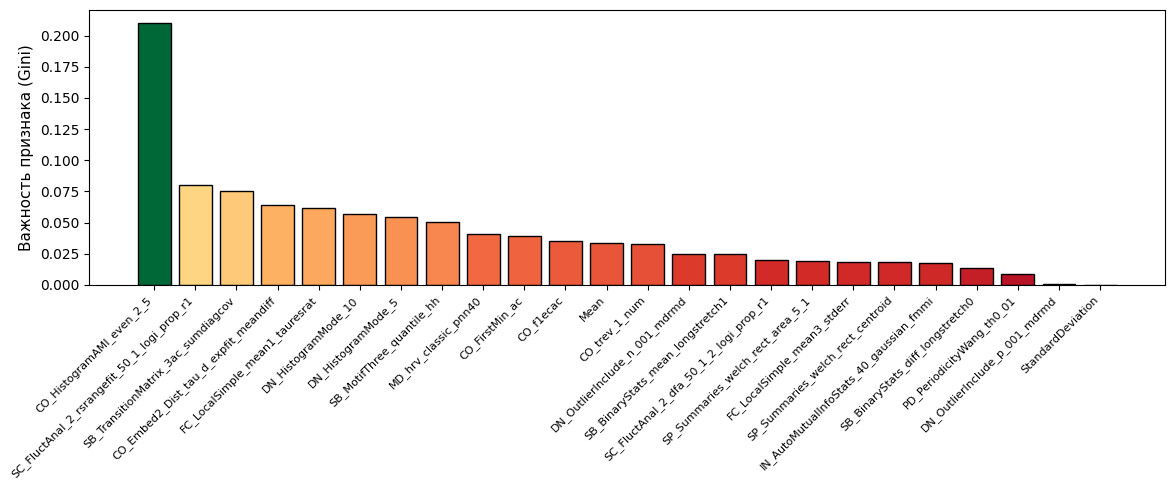

In [14]:
from aeon.transformations.collection.feature_based._catch22 import feature_names

all_feature_names = feature_names + ["Mean", "StandardDeviation"]

importances = gb.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(all_feature_names)), importances[sorted_idx],
        color=plt.cm.RdYlGn(importances[sorted_idx] / importances.max()),
        edgecolor='black')
plt.xticks(range(len(all_feature_names)),
           [all_feature_names[i] for i in sorted_idx],
           rotation=45, ha='right', fontsize=8)
plt.ylabel("Важность признака (Gini)", fontsize=11)
plt.tight_layout()
plt.show()

Самый важный CO_HistogramAMI_even_2_5 это мера взаимной информации на основе гистограммы амплитуд, фактически оценивающая сложность распределения значений сигнала. распределения уровней громкости у кошек и собак различаются сильнее всего

SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1 - флуктуационный анализ (масштабные колебания ряда).

SB_TransitionMatrix_3ac_sumdiagcov - структура переходов между состояниями (возрастание/убывание/плато).

CO_Embed2_Dist_tau_d_expfit_meandiff - поведение точек в фазовом пространстве.

FC_LocalSimple_mean1_tauresrat - локальные средние.
Эти признаки описывают динамику и регулярность сигнала протяжное мяуканье или рваный лай.

### Deep Learning: sklearn MLP (3 конфигурации)

MLP мелкая (64): 0.4817 (48.17%)
MLP средняя (128, 64): 0.4512 (45.12%)
MLP глубокая (256,128,64): 0.5244 (52.44%)


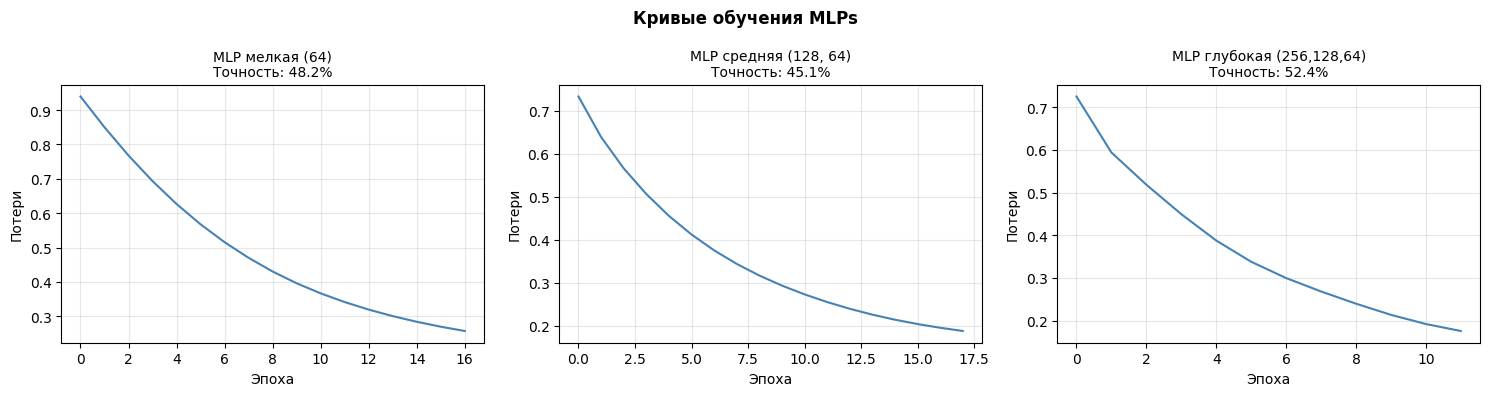

In [16]:
from sklearn.neural_network import MLPClassifier as SklearnMLP

y_train_int = y_train.astype(int)
y_test_int  = y_test.astype(int)

X_tr_2d = X_train_aeon_scaled[:, 0, :]
X_te_2d = X_test_aeon_scaled[:,  0, :]

mlp_configs = {
    "MLP мелкая (64)":           SklearnMLP(hidden_layer_sizes=(64,),        max_iter=300, random_state=42, early_stopping=True),
    "MLP средняя (128, 64)":     SklearnMLP(hidden_layer_sizes=(128, 64),    max_iter=300, random_state=42, early_stopping=True),
    "MLP глубокая (256,128,64)": SklearnMLP(hidden_layer_sizes=(256,128,64), max_iter=300, random_state=42, early_stopping=True),
}

acc_mlp_results = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, mlp) in zip(axes, mlp_configs.items()):
    mlp.fit(X_tr_2d, y_train_int)
    acc = accuracy_score(y_test_int, mlp.predict(X_te_2d))
    acc_mlp_results[name] = acc
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")
    ax.plot(mlp.loss_curve_, color='steelblue', linewidth=1.5)
    ax.set_title(f"{name}\nТочность: {acc*100:.1f}%", fontsize=10)
    ax.set_xlabel("Эпоха")
    ax.set_ylabel("Потери")
    ax.grid(True, alpha=0.3)

plt.suptitle("Кривые обучения MLPs", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


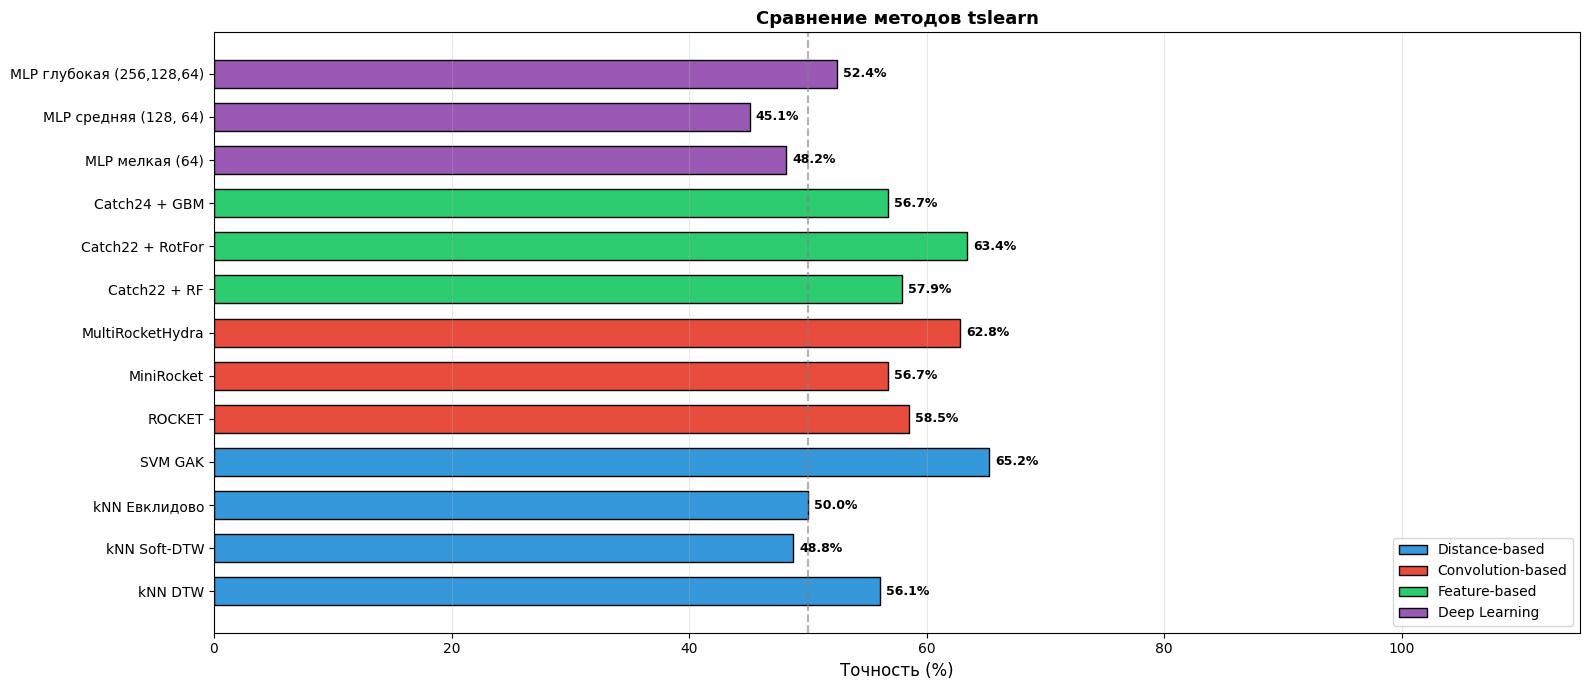


 Итоговая таблица (по убыванию точности):
Метод                                 Точность Группа
-----------------------------------------------------------------
SVM GAK                                 65.24%   Distance-based
Catch22 + RotFor                        63.41%   Feature-based
MultiRocketHydra                        62.80%   Convolution-based
ROCKET                                  58.54%   Convolution-based
Catch22 + RF                            57.93%   Feature-based
MiniRocket                              56.71%   Convolution-based
Catch24 + GBM                           56.71%   Feature-based
kNN DTW                                 56.10%   Distance-based
MLP глубокая (256,128,64)               52.44%   Deep Learning
kNN Евклидово                           50.00%   Distance-based
kNN Soft-DTW                            48.78%   Distance-based
MLP мелкая (64)                         48.17%   Deep Learning
MLP средняя (128, 64)                   45.12%   Deep Learning


In [18]:
# Собираем все результаты
all_results = {
    # Distance-based
    "kNN DTW":           acc_knn_dtw,
    "kNN Soft-DTW":      acc_knn_sdtw,
    "kNN Евклидово":     acc_knn_euc,
    "SVM GAK":           acc_svc,
    # Convolution-based
    "ROCKET":            acc_rocket,
    "MiniRocket":        acc_mini,
    "MultiRocketHydra":  acc_mrh,
    # Feature-based
    "Catch22 + RF":      acc_c22_rf,
    "Catch22 + RotFor":  acc_c22_rot,
    "Catch24 + GBM":     acc_c22_gb,
}
# Deep learning
for name, acc in acc_mlp_results.items():
    all_results[name] = acc
if 'acc_dl_results' in dir() and acc_dl_results != acc_mlp_results:
    for name, acc in acc_dl_results.items():
        all_results[name] = acc

# Группы для цветовой раскраски
groups = {
    "Distance-based":    ["kNN DTW", "kNN Soft-DTW", "kNN Евклидово", "SVM GAK"],
    "Convolution-based": ["ROCKET", "MiniRocket", "MultiRocketHydra"],
    "Feature-based":     ["Catch22 + RF", "Catch22 + RotFor", "Catch24 + GBM"],
}
group_colors = {"Distance-based": "#3498db", "Convolution-based": "#e74c3c", "Feature-based": "#2ecc71"}
default_color = "#9b59b6"

names  = list(all_results.keys())
values = [all_results[n] * 100 for n in names]
bar_colors = []
for n in names:
    assigned = default_color
    for g, members in groups.items():
        if n in members:
            assigned = group_colors[g]
            break
    bar_colors.append(assigned)

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.barh(names, values, color=bar_colors, edgecolor='black', height=0.65)
ax.axvline(50, color='gray', linestyle='--', alpha=0.6, label='Случайное угадывание (50%)')
ax.set_xlabel("Точность (%)", fontsize=12)
ax.set_title("Сравнение методов tslearn", fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va='center', ha='left', fontsize=9, fontweight='bold')

# Легенда групп
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=g)
                   for g, c in group_colors.items()]
legend_elements.append(Patch(facecolor=default_color, edgecolor='black', label='Deep Learning'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Итоговая таблица (по убыванию точности):")
print(f"{'Метод':<35} {'Точность':>10} {'Группа'}")
print("-" * 65)
group_lookup = {n: g for g, members in groups.items() for n in members}
for name in sorted(all_results, key=lambda x: -all_results[x]):
    g = group_lookup.get(name, "Deep Learning")
    print(f"{name:<35} {all_results[name]*100:>9.2f}%   {g}")

Лучший результат SVM с ядром GAK (65.2%)

Для задачи классификации коротких акустических записей при малом объёме данных (164 примера) оптимальным является сочетание kernel-метода с GAK или признакового подхода с ансамблем деревьев (Catch22 + RotationForest). Свёрточные методы (ROCKET-семейство) эт надёжный универсальный выбор при отсутствии времени на настройку гиперпараметров